<a href="https://colab.research.google.com/github/its-nks/Churn_Prediction/blob/main/Customer_Churrn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [396]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [397]:
df=pd.read_excel("Telco_customer_churn.xlsx")

In [398]:
df.shape

(7043, 33)

In [399]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [400]:
df['Churn Label'].value_counts()


,count
Churn Label,
No,5174
Yes,1869


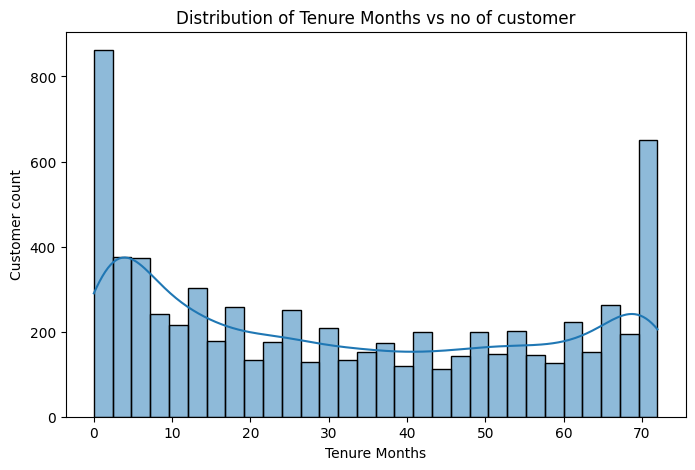

In [401]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'], bins=30, kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Months vs no of customer')
plt.show()

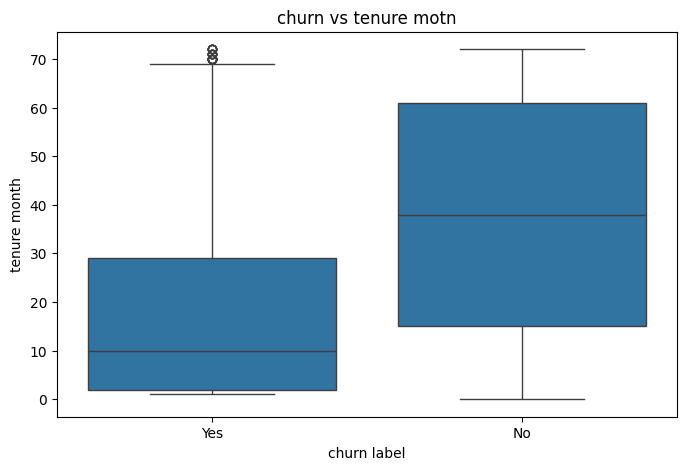

In [402]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Tenure Months' , data=df)
plt.xlabel('churn label')
plt.ylabel('tenure month')
plt.title('churn vs tenure motn')
plt.show()

In [403]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

In [404]:
df [df['Churn Label']=='Yes']

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1864,1699-HPSBG,1,United States,California,Palm Springs,92264,"33.745746, -116.514215",33.745746,-116.514215,Male,...,One year,Yes,Electronic check,59.80,727.8,Yes,1,69,4581,Competitor offered higher download speeds
1865,8775-CEBBJ,1,United States,California,Seeley,92273,"32.790282, -115.689559",32.790282,-115.689559,Female,...,Month-to-month,Yes,Bank transfer (automatic),44.20,403.35,Yes,1,87,2029,Competitor offered higher download speeds
1866,6894-LFHLY,1,United States,California,Vidal,92280,"34.264124, -114.717964",34.264124,-114.717964,Male,...,Month-to-month,Yes,Electronic check,75.75,75.75,Yes,1,97,5571,Competitor offered higher download speeds
1867,0639-TSIQW,1,United States,California,White Water,92282,"33.972293, -116.654195",33.972293,-116.654195,Female,...,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes,1,70,5620,Competitor offered more data


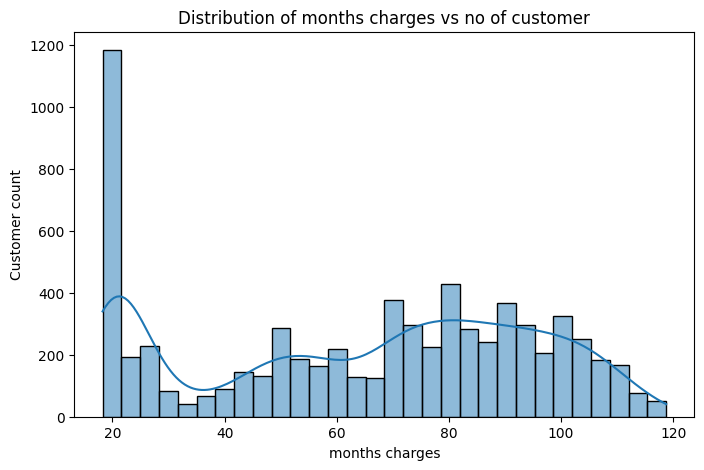

In [405]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'], bins=30, kde=True)
plt.xlabel('months charges')
plt.ylabel('Customer count')
plt.title('Distribution of months charges vs no of customer')
plt.show()

In [406]:
df['Monthly Charges'].max()

118.75

In [407]:
df['Monthly Charges'].min()

18.25

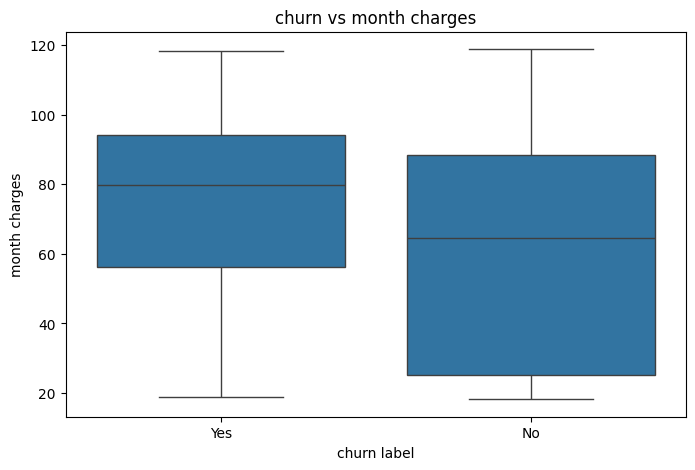

In [408]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Monthly Charges' , data=df)
plt.xlabel('churn label')
plt.ylabel('month charges')
plt.title('churn vs month charges')
plt.show()

In [409]:
df [df['Churn Label']=='Yes'] ['Monthly Charges'].quantile ([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [410]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [411]:
df['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,35.50
0.50,70.35
0.75,89.85


In [412]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

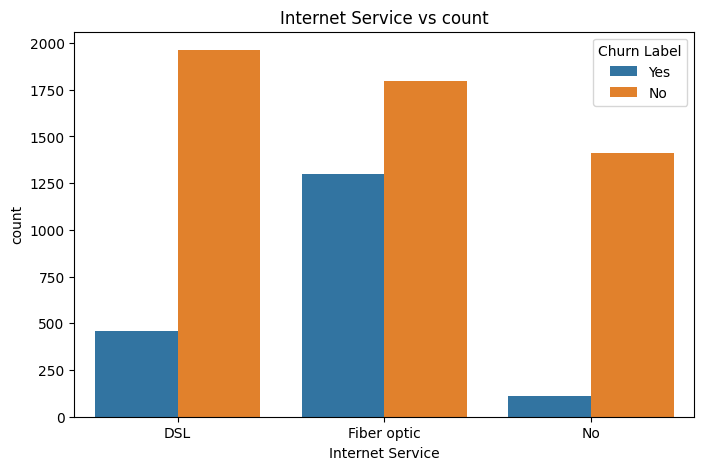

In [413]:
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service', hue='Churn Label', data=df)
plt.xlabel('Internet Service')
plt.ylabel('count')
plt.title('Internet Service vs count')
plt.show()

In [414]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

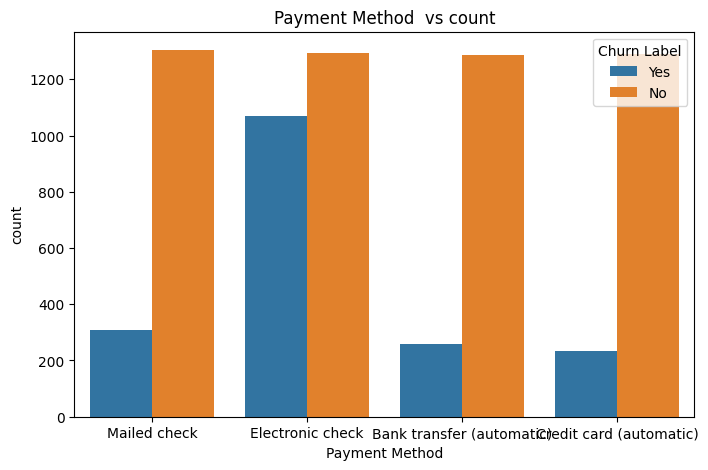

In [415]:
plt.figure(figsize=(8,5))
sns.countplot(x='Payment Method', hue='Churn Label', data=df)
plt.xlabel('Payment Method')
plt.ylabel('count')
plt.title('Payment Method  vs count')
plt.show()

In [416]:
avg_tenure=df.groupby("Churn Label")['Tenure Months'].mean()

In [417]:
avg_tenure=df.groupby("Churn Label")['Tenure Months'].mean()

In [418]:
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [419]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [420]:
numerical_cols = ['Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']
correlation_matrix = df[numerical_cols].corr()

In [421]:
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


In [422]:
contract_churn = pd.crosstab(df['Contract'], df['Churn Label'], normalize='index')


In [423]:
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


**Data cleaning**

In [424]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [425]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [426]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [427]:
df['Total Charges'].dtype

dtype('float64')

In [428]:
df[['Total Charges', 'Tenure Months']].isnull().sum()

,0
Total Charges,11
Tenure Months,0


In [429]:
# Show specific columns where 'Total Charges' is missing
df.loc[df['Total Charges'].isnull(), ['Total Charges', 'Tenure Months']]

,Total Charges,Tenure Months
2234,NaN,0
2438,NaN,0
2568,NaN,0
2667,NaN,0
2856,NaN,0
4331,NaN,0
4687,NaN,0
5104,NaN,0
5719,NaN,0
6772,NaN,0


In [430]:
#Returns a DataFrame showing the 'Tenure Months' values for all rows where 'Total Charges' is missing
df[df['Total Charges'].isnull()][['Tenure Months']]

,Tenure Months
2234,0
2438,0
2568,0
2667,0
2856,0
4331,0
4687,0
5104,0
5719,0
6772,0


In [431]:
# 2. Corrected drop (without StateID)
drop_columns = ['CustomerID', 'Count', 'Country', 'State', 'Zip Code', 'Lat Long','Latitude','Longitude']
df = df.drop(columns=drop_columns)

In [432]:
# 3. Check shape after dropping
df.shape


(7043, 25)

City Encoding

In [433]:
df['City'].unique()

df['City'].value_counts()

,count
City,
Los Angeles,305
San Diego,150
San Jose,112
Sacramento,108
San Francisco,104
...,...
Chester,4
Big Bar,4
Washington,4


In [434]:
df = df.drop(columns=['City'])

In [435]:
# 4. Get dataframe info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [436]:
# Remove leakage columns BEFORE encoding

leakage_columns = ['Churn Label','Churn Score','CLTV']

In [437]:
df = df.drop(columns=leakage_columns)

In [438]:
# Create dummy variables
df_encoded = pd.get_dummies(df, drop_first=True)


In [439]:
# Features and target
X = df_encoded.drop('Churn Value', axis=1)
y = df_encoded['Churn Value']

In [440]:
print(X.shape)
print(y.shape)

(7043, 49)
(7043,)


In [441]:
print(X.head())
print(y.head())

   Tenure Months  Monthly Charges  Total Charges  Gender_Male  \
0              2            53.85         108.15         True   
1              2            70.70         151.65        False   
2              8            99.65         820.50        False   
3             28           104.80        3046.05        False   
4             49           103.70        5036.30         True   

   Senior Citizen_Yes  Partner_Yes  Dependents_Yes  Phone Service_Yes  \
0               False        False           False               True   
1               False        False            True               True   
2               False        False            True               True   
3               False         True            True               True   
4               False        False            True               True   

   Multiple Lines_No phone service  Multiple Lines_Yes  ...  \
0                            False               False  ...   
1                            False          

Machine learning implementation

In [442]:
# 15. Import train_test_split
from sklearn.model_selection import train_test_split

In [443]:
# 16. Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [444]:
# 17. Check shapes of splits
X_train.shape

(5634, 49)

In [445]:
X_test.shape

(1409, 49)

In [446]:
y_train.shape

(5634,)

In [447]:
y_test.shape

(1409,)

In [448]:
# 18. Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

In [449]:
# 19. Create Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [450]:
# 20. Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [451]:
# 21. Make predictions
y_pred = rf_model.predict(X_test)

Apporach 1 -Handle class imbalance

In [452]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

In [453]:
# 22. View actual test values
y_test

,Churn Value
2196,0
3549,0
3515,0
5162,0
4642,0
...,...
5660,0
5150,0
4708,0
5381,0


In [454]:
# 23. View predictions
y_pred

array([0, 1, 0, ..., 0, 0, 0])

Approach 2 :Hyperparameter Tuning

In [455]:
rf_tuned = RandomForestClassifier(
    n_estimators=350,
    max_depth=11,
    random_state=42,
    class_weight='balanced'
)

In [456]:
rf_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=11, n_estimators=350,
                       random_state=42)

In [457]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_tuned.feature_importances_
})

feature_importances = feature_importances.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importances.head(20))

                                              Feature  Importance
0                                       Tenure Months    0.108404
25                                  Contract_Two year    0.091949
2                                       Total Charges    0.089450
6                                      Dependents_Yes    0.065139
10                       Internet Service_Fiber optic    0.063451
1                                     Monthly Charges    0.047807
28                    Payment Method_Electronic check    0.043602
33  Churn Reason_Competitor offered higher downloa...    0.042368
30            Churn Reason_Attitude of support person    0.040013
34          Churn Reason_Competitor offered more data    0.029899
24                                  Contract_One year    0.029216
36                            Churn Reason_Don't know    0.026714
13                                Online Security_Yes    0.024175
32          Churn Reason_Competitor made better offer    0.022378
47        

In [458]:
print(rf_tuned)

RandomForestClassifier(class_weight='balanced', max_depth=11, n_estimators=350,
                       random_state=42)


In [459]:
rf_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=11, n_estimators=350,
                       random_state=42)

In [460]:
y_pred_tuned = rf_tuned.predict(X_test)

In [461]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.94      0.84      0.89      1035
           1       0.66      0.84      0.74       374

    accuracy                           0.84      1409
   macro avg       0.80      0.84      0.81      1409
weighted avg       0.86      0.84      0.85      1409



In [462]:
# 24. Import accuracy_score
from sklearn.metrics import accuracy_score

In [463]:
# 25. Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

In [464]:
# 26. Print accuracy
print(accuracy)

0.9652235628105039


In [465]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Metrics for Baseline RF (rf_model)
acc1 = accuracy_score(y_test, y_pred)
report_baseline = classification_report(y_test, y_pred, output_dict=True)
pre1 = report_baseline['1']['precision']
rec1 = report_baseline['1']['recall']
f11 = report_baseline['1']['f1-score']

# Metrics for Balanced RF (rf_balanced)
rf_balanced.fit(X_train, y_train) # Fit the balanced model
y_pred_balanced = rf_balanced.predict(X_test)
acc2 = accuracy_score(y_test, y_pred_balanced)
report_balanced = classification_report(y_test, y_pred_balanced, output_dict=True)
pre2 = report_balanced['1']['precision']
rec2 = report_balanced['1']['recall']
f12 = report_balanced['1']['f1-score']

# Metrics for Tuned RF (rf_tuned)
# The predictions are already available as y_pred_tuned
acc3 = accuracy_score(y_test, y_pred_tuned)
report_tuned = classification_report(y_test, y_pred_tuned, output_dict=True)
pre3 = report_tuned['1']['precision']
rec3 = report_tuned['1']['recall']
f13 = report_tuned['1']['f1-score']

comparison = pd.DataFrame({
    "Model": ["Baseline RF", "Balanced RF", "Tuned RF"],
    "Accuracy": [acc1, acc2, acc3],
    "Precision": [pre1, pre2, pre3],
    "Recall": [rec1, rec2, rec3],
    "F1 Score": [f11, f12, f13]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline RF,0.965224,0.952646,0.914439,0.933151
1,Balanced RF,0.922640,0.928803,0.767380,0.840410
2,Tuned RF,0.841732,0.656965,0.844920,0.739181


In [466]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1018   17]
 [  32  342]]


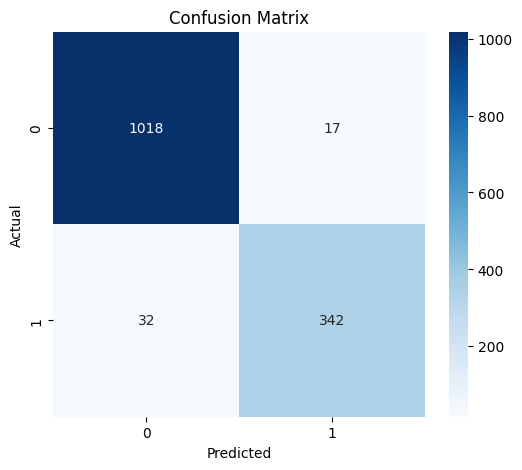

In [467]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [468]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1035
           1       0.95      0.91      0.93       374

    accuracy                           0.97      1409
   macro avg       0.96      0.95      0.95      1409
weighted avg       0.97      0.97      0.96      1409




Feature Importance

In [469]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                                              Feature  Importance
2                                       Total Charges    0.088723
0                                       Tenure Months    0.078933
1                                     Monthly Charges    0.064752
33  Churn Reason_Competitor offered higher downloa...    0.058726
30            Churn Reason_Attitude of support person    0.057203
36                            Churn Reason_Don't know    0.047603
34          Churn Reason_Competitor offered more data    0.047252
32          Churn Reason_Competitor made better offer    0.041541
31         Churn Reason_Competitor had better devices    0.035459
47               Churn Reason_Product dissatisfaction    0.034361


Cross Validation

In [470]:
from sklearn.model_selection import cross_val_score

cv_accuracy = cross_val_score(
    rf_tuned,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print(cv_accuracy)
print("Mean Accuracy:", cv_accuracy.mean())

[0.83818311 0.86657204 0.83747339 0.85298295 0.85582386]
Mean Accuracy: 0.8502070698109556


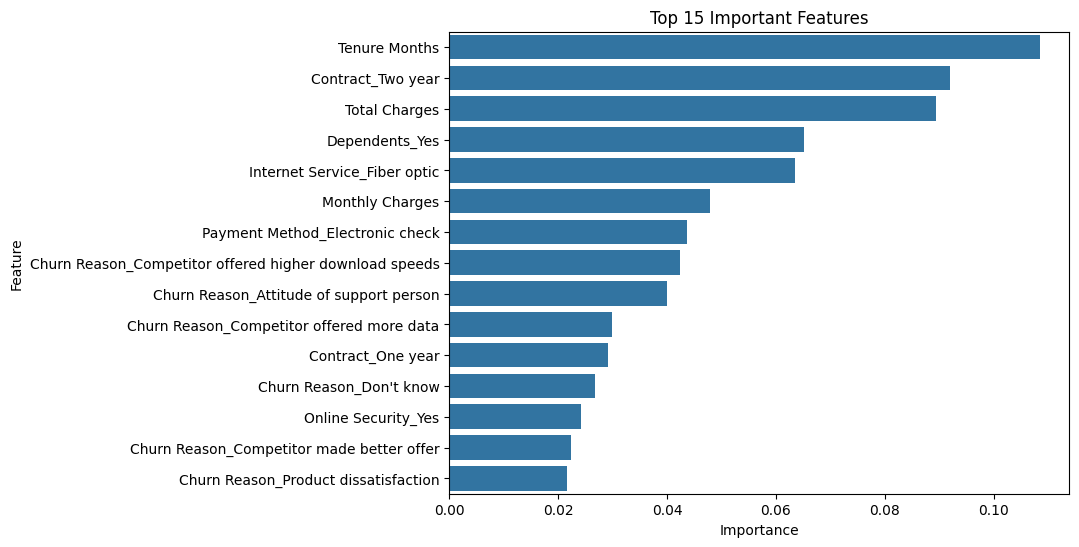

In [472]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_tuned.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.savefig("feature_importance.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

**Customer Segmentation**

In [473]:
y_prob1=rf_tuned.predict_proba(X_test)

In [474]:
churn_prob= y_prob1[:,1]

In [475]:
y_prob1=rf_tuned.predict_proba(X_test)

In [476]:
y_prob=rf_tuned.predict_proba(X_test)

In [477]:
churn_probability= y_prob[:,1]

In [478]:
segmentation_data=pd.DataFrame({
  'Tenure Months':X_test['Tenure Months'],
  'Monthly Charges':X_test['Monthly Charges'],
  'Total Charges':X_test['Total Charges'],
  'Churn Probability':churn_probability})
# Drop rows with NaN values before scaling
segmentation_data.dropna(inplace=True)

In [479]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
2196,72,114.05,8468.20,0.063910
3549,8,100.15,908.55,0.768027
3515,41,78.35,3211.20,0.165664
5162,18,78.20,1468.75,0.567111
4642,72,82.65,5919.35,0.040609
...,...,...,...,...
5660,49,87.20,4345.00,0.065999
5150,28,20.30,487.95,0.009761
4708,5,20.65,93.55,0.123602
5381,56,19.70,1051.90,0.054096


**Implementation of Kmeans**

In [480]:
from sklearn.preprocessing import StandardScaler


In [481]:
scaler = StandardScaler()

In [482]:
# Ensure segmentation_data is clean of NaNs right before scaling
segmentation_data.dropna(inplace=True)
print(f"Shape of segmentation_data after dropna: {segmentation_data.shape}")
scaled_data=scaler.fit_transform(segmentation_data)
print(scaled_data[:5])

Shape of segmentation_data after dropna: (1406, 4)
[[ 1.63339708  1.67092548  2.82743528 -0.9773513 ]
 [-0.97896989  1.20557348 -0.58584088  1.38283365]
 [ 0.36803183  0.47574084  0.45383428 -0.63627342]
 [-0.57078755  0.47071905 -0.3329036   0.70936657]
 [ 1.63339708  0.61969865  1.67659775 -1.05545342]]


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

...

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

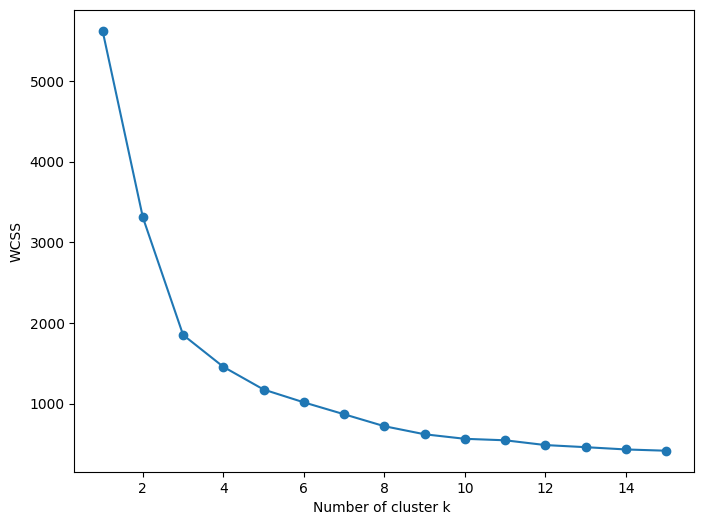

In [483]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,16):
  kmeans=KMeans(n_clusters=k, random_state=42)
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)
  plt.figure(figsize=(8,6))
plt.plot(range(1,16),wcss,marker='o')
plt.xlabel("Number of cluster k ")
plt.ylabel("WCSS")
plt.show()

In [484]:
kmeans = KMeans(n_clusters = 3 , random_state=42)

In [485]:
clusters = kmeans.fit_predict(scaled_data)

In [486]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
2196,72,114.05,8468.20,0.063910
3549,8,100.15,908.55,0.768027
3515,41,78.35,3211.20,0.165664
5162,18,78.20,1468.75,0.567111
4642,72,82.65,5919.35,0.040609
...,...,...,...,...
5660,49,87.20,4345.00,0.065999
5150,28,20.30,487.95,0.009761
4708,5,20.65,93.55,0.123602
5381,56,19.70,1051.90,0.054096


In [487]:
segmentation_data['cluster'] = clusters

In [488]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,cluster
2196,72,114.05,8468.20,0.063910,0
3549,8,100.15,908.55,0.768027,1
3515,41,78.35,3211.20,0.165664,0
5162,18,78.20,1468.75,0.567111,1
4642,72,82.65,5919.35,0.040609,0
...,...,...,...,...,...
5660,49,87.20,4345.00,0.065999,0
5150,28,20.30,487.95,0.009761,2
4708,5,20.65,93.55,0.123602,2
5381,56,19.70,1051.90,0.054096,2


In [489]:
cluster_summary=segmentation_data.groupby('cluster').mean()

In [490]:
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
cluster,,,,
0,58.206468,90.669776,5276.542662,0.217446
1,11.278409,72.327178,897.954735,0.670647
2,32.804622,32.652101,1063.921954,0.122470


In [491]:
cluster_summary = {
    0:'Budget Loyal Customer',
    1:'High Risk New Customer',
    2:'Loyal Premimum Customer'
}

In [492]:
segmentation_data['Cluster Segment']=segmentation_data['cluster'].map(cluster_summary)

In [493]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,cluster,Cluster Segment
2196,72,114.05,8468.20,0.063910,0,Budget Loyal Customer
3549,8,100.15,908.55,0.768027,1,High Risk New Customer
3515,41,78.35,3211.20,0.165664,0,Budget Loyal Customer
5162,18,78.20,1468.75,0.567111,1,High Risk New Customer
4642,72,82.65,5919.35,0.040609,0,Budget Loyal Customer
...,...,...,...,...,...,...
5660,49,87.20,4345.00,0.065999,0,Budget Loyal Customer
5150,28,20.30,487.95,0.009761,2,Loyal Premimum Customer
4708,5,20.65,93.55,0.123602,2,Loyal Premimum Customer
5381,56,19.70,1051.90,0.054096,2,Loyal Premimum Customer


<Axes: xlabel='Monthly Charges', ylabel='Churn Probability'>

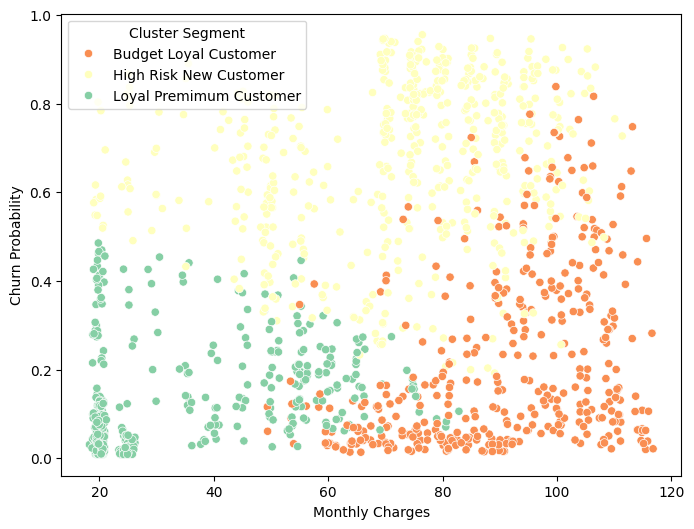

In [494]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Monthly Charges', y='Churn Probability', hue='Cluster Segment', data=segmentation_data, palette='Spectral')

<Axes: xlabel='Tenure Months', ylabel='Churn Probability'>

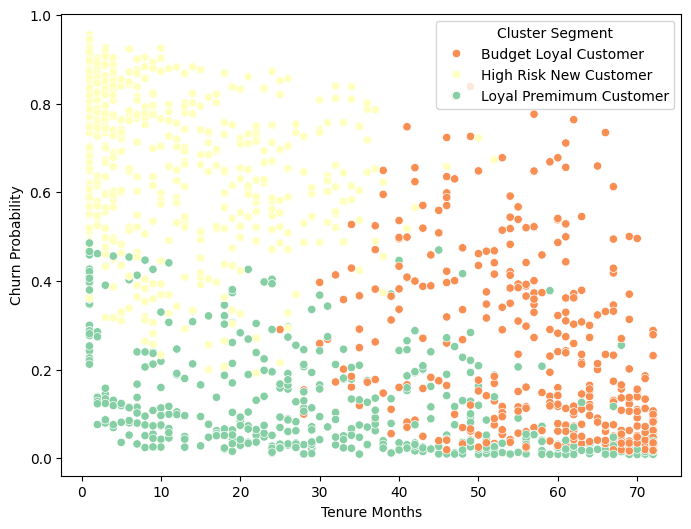

In [495]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Tenure Months', y='Churn Probability', hue='Cluster Segment', data=segmentation_data, palette='Spectral')

<Axes: xlabel='Total Charges', ylabel='Churn Probability'>

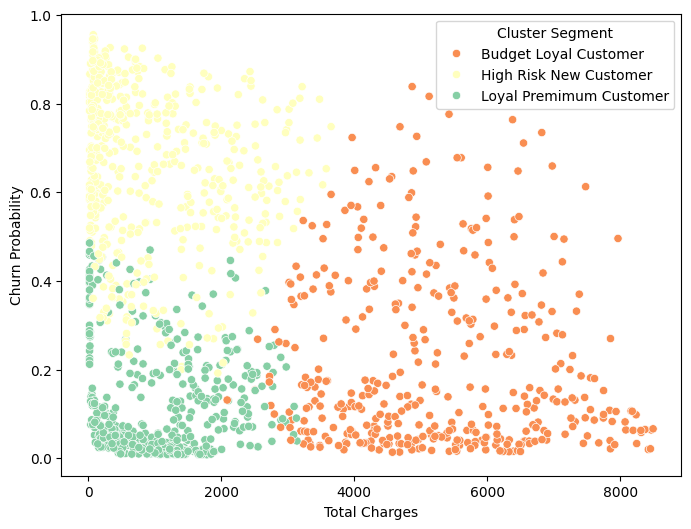

In [496]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Total Charges', y='Churn Probability', hue='Cluster Segment', data=segmentation_data, palette='Spectral')

In [497]:
# Assuming optimal k=4 based on the elbow method (adjust if your plot suggests otherwise)
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init='auto')
segmentation_data['Cluster'] = kmeans.fit_predict(scaled_data)

print(segmentation_data.head())

      Tenure Months  Monthly Charges  Total Charges  Churn Probability  \
2196             72           114.05        8468.20           0.063910   
3549              8           100.15         908.55           0.768027   
3515             41            78.35        3211.20           0.165664   
5162             18            78.20        1468.75           0.567111   
4642             72            82.65        5919.35           0.040609   

      cluster         Cluster Segment  Cluster  
2196        0   Budget Loyal Customer        0  
3549        1  High Risk New Customer        1  
3515        0   Budget Loyal Customer        0  
5162        1  High Risk New Customer        1  
4642        0   Budget Loyal Customer        0  
